<h1>Table of Contents<span class="tocSkip"></span></h1>
<div class="toc"><ul class="toc-item"><li><span><a href="#Goal" data-toc-modified-id="Goal-1"><span class="toc-item-num">1&nbsp;&nbsp;</span>Goal</a></span></li><li><span><a href="#Var" data-toc-modified-id="Var-2"><span class="toc-item-num">2&nbsp;&nbsp;</span>Var</a></span></li><li><span><a href="#Init" data-toc-modified-id="Init-3"><span class="toc-item-num">3&nbsp;&nbsp;</span>Init</a></span></li><li><span><a href="#Load" data-toc-modified-id="Load-4"><span class="toc-item-num">4&nbsp;&nbsp;</span>Load</a></span><ul class="toc-item"><li><span><a href="#Checks" data-toc-modified-id="Checks-4.1"><span class="toc-item-num">4.1&nbsp;&nbsp;</span>Checks</a></span><ul class="toc-item"><li><span><a href="#Filtering-count-table" data-toc-modified-id="Filtering-count-table-4.1.1"><span class="toc-item-num">4.1.1&nbsp;&nbsp;</span>Filtering count table</a></span></li><li><span><a href="#Converting-counts-to-wide-matrix" data-toc-modified-id="Converting-counts-to-wide-matrix-4.1.2"><span class="toc-item-num">4.1.2&nbsp;&nbsp;</span>Converting counts to wide matrix</a></span></li></ul></li><li><span><a href="#Formatting-trees" data-toc-modified-id="Formatting-trees-4.2"><span class="toc-item-num">4.2&nbsp;&nbsp;</span>Formatting trees</a></span></li></ul></li><li><span><a href="#Alpha-div-measures" data-toc-modified-id="Alpha-div-measures-5"><span class="toc-item-num">5&nbsp;&nbsp;</span>Alpha div measures</a></span><ul class="toc-item"><li><span><a href="#PD" data-toc-modified-id="PD-5.1"><span class="toc-item-num">5.1&nbsp;&nbsp;</span>PD</a></span></li><li><span><a href="#MNTD" data-toc-modified-id="MNTD-5.2"><span class="toc-item-num">5.2&nbsp;&nbsp;</span>MNTD</a></span><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Writing-table" data-toc-modified-id="Writing-table-5.2.0.1"><span class="toc-item-num">5.2.0.1&nbsp;&nbsp;</span>Writing table</a></span></li></ul></li></ul></li><li><span><a href="#MPD" data-toc-modified-id="MPD-5.3"><span class="toc-item-num">5.3&nbsp;&nbsp;</span>MPD</a></span><ul class="toc-item"><li><ul class="toc-item"><li><span><a href="#Writing-table" data-toc-modified-id="Writing-table-5.3.0.1"><span class="toc-item-num">5.3.0.1&nbsp;&nbsp;</span>Writing table</a></span></li></ul></li></ul></li><li><span><a href="#Summary" data-toc-modified-id="Summary-5.4"><span class="toc-item-num">5.4&nbsp;&nbsp;</span>Summary</a></span><ul class="toc-item"><li><span><a href="#Explore" data-toc-modified-id="Explore-5.4.1"><span class="toc-item-num">5.4.1&nbsp;&nbsp;</span>Explore</a></span></li></ul></li><li><span><a href="#LMER" data-toc-modified-id="LMER-5.5"><span class="toc-item-num">5.5&nbsp;&nbsp;</span>LMER</a></span><ul class="toc-item"><li><span><a href="#Westernized" data-toc-modified-id="Westernized-5.5.1"><span class="toc-item-num">5.5.1&nbsp;&nbsp;</span>Westernized</a></span></li><li><span><a href="#Westernized-+-age-+-gender" data-toc-modified-id="Westernized-+-age-+-gender-5.5.2"><span class="toc-item-num">5.5.2&nbsp;&nbsp;</span>Westernized + age + gender</a></span></li><li><span><a href="#Westernized-+-age-+-gender-+-BMI" data-toc-modified-id="Westernized-+-age-+-gender-+-BMI-5.5.3"><span class="toc-item-num">5.5.3&nbsp;&nbsp;</span>Westernized + age + gender + BMI</a></span></li><li><span><a href="#Westernized-+-age-+-gender-+-disease-status" data-toc-modified-id="Westernized-+-age-+-gender-+-disease-status-5.5.4"><span class="toc-item-num">5.5.4&nbsp;&nbsp;</span>Westernized + age + gender + disease status</a></span></li><li><span><a href="#Merging:-models-1-2-3" data-toc-modified-id="Merging:-models-1-2-3-5.5.5"><span class="toc-item-num">5.5.5&nbsp;&nbsp;</span>Merging: models 1-2-3</a></span></li><li><span><a href="#Merging:-modesl-1-2-4" data-toc-modified-id="Merging:-modesl-1-2-4-5.5.6"><span class="toc-item-num">5.5.6&nbsp;&nbsp;</span>Merging: modesl 1-2-4</a></span></li></ul></li></ul></li><li><span><a href="#sessionInfo" data-toc-modified-id="sessionInfo-6"><span class="toc-item-num">6&nbsp;&nbsp;</span>sessionInfo</a></span></li></ul></div>

# Goal

* Run phylomeasures analysis on the dataset using the various trees as input
  * measures: mntd & mpd


# Var

In [127]:
# working dir
work_dir = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/'

# bracken counts
brk_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/bracken_filt.qs'

# metadata
## filtered
metadata_filt_file = file.path(work_dir, 'CurMetDat_metadata_filt-n1846.tsv')
## all 
base_in_dir = '/ebio/abt3_projects/small_projects/nyoungblut/public_data_retireval/'
metadata_file = file.path(base_in_dir, 'CurMetDat-metagenomes', 'files', 'metadata', 'Filtered_CurMetDat_f.tsv')

# trees
trees_file = '/ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/trees_ultrametric.RDS'

# params
threads = 12
my_seed = 68372

# Init

In [128]:
library(dplyr)
library(tidyr)
library(ggplot2)
library(data.table)
library(tidytable)
library(ape)
library(PhyloMeasures)
library(LeyLabRMisc)

In [129]:
df.dims()
setDTthreads(threads)
RhpcBLASctl::blas_set_num_threads(threads)
make_dir(work_dir)

Directory already exists: /ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity/ 


In [130]:
clustermq_setup(scheduler='multicore')   
library(clustermq)

# Load

In [84]:
# sample metadata
meta = Fread(metadata_file) %>%
    mutate.(Sample = gsub('-', '.', Sample)) %>%
    filter.(number_reads >= 5e5)
meta

dataset_name,Sample,subjectID,body_site,antibiotics_current_use,study_condition,disease,age,age_category,gender,⋯,il_1,glp_1,travel_destination,urea_nitrogen,disease_stage,uncurated_metadata,family_member,subject_n,samp_n,westernized
<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<int>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<lgl>
AsnicarF_2017,MV_FEM1_t1Q14,MV_FEM1,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
AsnicarF_2017,MV_FEM2_t1Q14,MV_FEM2,stool,NA,control,healthy,NA,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
ZellerG_2014,CCIS82944710ST.20.0,FR-730,stool,NA,control,healthy,38,adult,female,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
ZellerG_2014,CCIS93040568ST.20.0,FR-682,stool,NA,control,healthy,65,adult,male,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE


In [85]:
# Bracken count table
brk = qs::qread(brk_file, nthreads=threads) %>%
    mutate.(name = gsub(' ', '_', name))
brk 

dataset,name,taxonomy_id,taxonomy_lvl,Domain,Phylum,Class,Order,Family,Genus,Species,Sample,Abundance
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
CosteaPI_2017,s__Caecibacter_massiliensis,108259,S,Bacteria,Firmicutes_C,Negativicutes,Veillonellales,Megasphaeraceae,Caecibacter,Caecibacter massiliensis,halbarad.11.0.0,0
CosteaPI_2017,s__UBA1777_sp002350825,178550,S,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Oscillospiraceae,UBA1777,UBA1777 sp002350825,halbarad.11.0.0,0
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
YuJ_2015,s__Serratia_grimesii,121568,S,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Serratia,Serratia grimesii,SZAXPI017592.142,0
YuJ_2015,s__Bacteroides_A_sp002161565,119189,S,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides_A,Bacteroides_A sp002161565,SZAXPI017592.142,0


In [86]:
# trees
trees = readRDS(trees_file)
trees 

$gtdb_phy

Phylogenetic tree with 23360 tips and 23359 internal nodes.

Tip labels:
  s__Halorubrum_sp000296615, s__Halorubrum_distributum, s__Halorubrum_trapanicum, s__Halorubrum_tropicale, s__Halorubrum_coriense, s__Halorubrum_ezzemoulense, ...
Node labels:
  100.0, d__Archaea100.0, 97.0, 99.0, 100.0, 100.0-p__Halobacterota, ...

Rooted; includes branch lengths.

$trt_phy

Phylogenetic tree with 23360 tips and 23359 internal nodes.

Tip labels:
  s__Mikella_endobia, s__Prochlorococcus_B_sp003284185, s__Prochlorococcus_A_sp003282425, s__Eperythrozoon_A_wenyonii_A, s__GN02-872_sp003260325, s__SZUA-486_sp003251635, ...
Node labels:
  , 1, 1, 1, 1, 1, ...

Rooted; includes branch lengths.

$phy_cog

Phylogenetic tree with 23360 tips and 23359 internal nodes.

Tip labels:
  s__UBA9959_sp001799795, s__2-02-FULL-45-21_sp001805845, s__UBA11600_sp002717745, s__UBA11600_sp002714165, s__UBA11600_sp002730735, s__LS-NOB_sp002705185, ...
Node labels:
  , 1, 1, 1, 1, 1, ...

Rooted; includes branch

In [87]:
# check for ultrametric
trees %>% lapply(is.ultrametric)

$gtdb_phy
[1] TRUE

$trt_phy
[1] TRUE

$phy_cog
[1] TRUE

$phy_cogcat
[1] TRUE

$phy_pfam
[1] TRUE

$phy_pfamcat
[1] TRUE

In [88]:
# summary of branch lengths
trees %>%
    lapply(function(x) x$edge.length %>% summary_x)

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean
.,1e-04,0.02771,0.78404,0.8491699,1.652378,3.24184,1.218,0.497
,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean
.,0.000956023,0.0223232,0.03741539,0.05168345,0.06275403,0.4990458,0.191,0.078
,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean
.,0.000485437,0.00719928,0.01387183,0.02315197,0.0262783,0.5000007,0.199,0.081
,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean
.,0.000754148,0.00308897,0.004627441,0.00917814,0.00712913,0.5000006,0.202,0.083
,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean
.,0.00246203,0.01989042,0.03613732,0.0525647,0.06686718,0.4997934,0.191,0.078
,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean


## Checks

In [89]:
# overlap of tip labels among trees
overlap(trees[['gtdb_phy']]$tip.label, trees[['trt_phy']]$tip.label)

intersect(x,y): 23360 
setdiff(x,y): 0 
setdiff(y,x): 0 
union(x,y): 23360 


In [90]:
# overlap with tips 
overlap(trees[['gtdb_phy']]$tip.label, brk$name)

intersect(x,y): 3550 
setdiff(x,y): 19810 
setdiff(y,x): 0 
union(x,y): 23360 


### Filtering count table

In [91]:
brk %>% unique_n('Samples', Sample)
x = meta %>% pull.(Sample) %>% unique
brk = brk %>%
    filter.(Sample %in% x)

brk %>% unique_n('Samples', Sample)
brk

No. of unique Samples: 3357 
No. of unique Samples: 3348 


dataset,name,taxonomy_id,taxonomy_lvl,Domain,Phylum,Class,Order,Family,Genus,Species,Sample,Abundance
<chr>,<chr>,<int>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<chr>,<dbl>
CosteaPI_2017,s__Caecibacter_massiliensis,108259,S,Bacteria,Firmicutes_C,Negativicutes,Veillonellales,Megasphaeraceae,Caecibacter,Caecibacter massiliensis,halbarad.11.0.0,0
CosteaPI_2017,s__UBA1777_sp002350825,178550,S,Bacteria,Firmicutes_A,Clostridia,Oscillospirales,Oscillospiraceae,UBA1777,UBA1777 sp002350825,halbarad.11.0.0,0
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
YuJ_2015,s__Serratia_grimesii,121568,S,Bacteria,Proteobacteria,Gammaproteobacteria,Enterobacterales,Enterobacteriaceae,Serratia,Serratia grimesii,SZAXPI017592.142,0
YuJ_2015,s__Bacteroides_A_sp002161565,119189,S,Bacteria,Bacteroidota,Bacteroidia,Bacteroidales,Bacteroidaceae,Bacteroides_A,Bacteroides_A sp002161565,SZAXPI017592.142,0


### Converting counts to wide matrix

In [92]:
m = brk %>%
    select.(Sample, name, Abundance) %>%
    pivot_wider.(name, Abundance) %>%
    mutate_across.(is.numeric, 
                   function(x) ifelse(is.na(x), 0, x)) %>%
    as.data.frame
rownames(m) = m$Sample
m$Sample = NULL
m

,s__1-14-0-10-34-76_sp002763075,s__1-19_sp001922585,s__14-2_sp000403255,s__14-2_sp000403315,s__14-2_sp000403845,s__14-2_sp001940225,s__2-01-FULL-39-21_sp001792305,s__2013-40CM-41-45_sp002215675,s__46-32_sp003243445,s__51-20_sp001917175,⋯,s__Zag111_sp002405805,s__Zag111_sp002438405,s__Zag111_sp003258735,s__Zag1_sp000433095,s__Zag1_sp000437435,s__Zag1_sp000438175,s__Zag1_sp001765415,s__Zag1_sp001917115,s__Zoogloea_sp002028455,s__Zunongwangia_mangrovi
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A01_02_1FE,0,0,0,0,0,0,0,0,0,0,⋯,0,0.00000,0,0,0,0,0.00000,0,0,0
A02_01_1FE,0,0,0,0,0,0,0,0,0,0,⋯,0,0.00036,0,0,0,0,0.00038,0,0,0
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,0,0,0,0,0,0e+00,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
scavenger.11.60.0,0,0,0,0,0,3e-04,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


In [93]:
# mean abundances
taxon_abund = m %>% apply(2, mean) %>% as.numeric
taxon_abund = taxon_abund * 100
#taxon_abund = runif(length(taxon_abund), 1, 10)
names(taxon_abund) = colnames(m)
taxon_abund %>% length
taxon_abund %>% summary_x

[1] 3550

,Min.,1st Qu.,Median,Mean,3rd Qu.,Max.,sd,sd_err_of_mean
.,6.869773e-06,4.988053e-05,0.0002108722,0.02816185,0.003008961,4.833783,1.971,0.805


In [94]:
# checking names overlap for abundance weight vector
overlap(names(taxon_abund), trees[['gtdb_phy']]$tip.label)

intersect(x,y): 3550 
setdiff(x,y): 0 
setdiff(y,x): 19810 
union(x,y): 23360 


In [95]:
# converting count matrix to pres-abs
m = m %>% apply(1, function(x) ifelse(x > 0, 1, 0)) %>% 
    t %>% as.data.frame
m

,s__1-14-0-10-34-76_sp002763075,s__1-19_sp001922585,s__14-2_sp000403255,s__14-2_sp000403315,s__14-2_sp000403845,s__14-2_sp001940225,s__2-01-FULL-39-21_sp001792305,s__2013-40CM-41-45_sp002215675,s__46-32_sp003243445,s__51-20_sp001917175,⋯,s__Zag111_sp002405805,s__Zag111_sp002438405,s__Zag111_sp003258735,s__Zag1_sp000433095,s__Zag1_sp000437435,s__Zag1_sp000438175,s__Zag1_sp001765415,s__Zag1_sp001917115,s__Zoogloea_sp002028455,s__Zunongwangia_mangrovi
,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,⋯,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>
A01_02_1FE,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
A02_01_1FE,0,0,0,0,0,0,0,0,0,0,⋯,0,1,0,0,0,0,1,0,0,0
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
nHMX11726,0,0,0,0,0,0,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0
scavenger.11.60.0,0,0,0,0,0,1,0,0,0,0,⋯,0,0,0,0,0,0,0,0,0,0


## Formatting trees

In [96]:
# pruning
filter_tree = function(tree, m){
    to_rm = setdiff(tree$tip.label, colnames(m))
    tree = drop.tip(tree, to_rm)
    return(tree)
}

trees_f = trees %>%
    lapply(filter_tree, m=m)
trees_f

$gtdb_phy

Phylogenetic tree with 3550 tips and 3549 internal nodes.

Tip labels:
  s__Halorubrum_sp002286985, s__Natrialba_hulunbeirensis, s__Methanocorpusculum_sp001940805, s__MGIIb-O1_sp002497025, s__Methanomethylophilus_alvus, s__Methanomethylophilus_sp001481295, ...
Node labels:
  100.0, d__Archaea100.0, 97.0, 99.0, 100.0, 98.0, ...

Rooted; includes branch lengths.

$trt_phy

Phylogenetic tree with 3550 tips and 3549 internal nodes.

Tip labels:
  s__GCA-2688265_sp002688265, s__UBA6534_sp002687905, s__UBA493_sp002687735, s__UBA71_sp002504495, s__UBA4647_sp002438625, s__UBA6345_sp002437945, ...
Node labels:
  , 1, 1, 1, 1, 1, ...

Rooted; includes branch lengths.

$phy_cog

Phylogenetic tree with 3550 tips and 3549 internal nodes.

Tip labels:
  s__Sphingomonas_echinoides, s__AG-422-E19_sp003213595, s__Acinetobacter_gerneri, s__Acinetobacter_bereziniae, s__GCA-002718655_sp002718655, s__2-01-FULL-39-21_sp001792305, ...
Node labels:
  1, 1, 1, 1, 1, 1, ...

Rooted; includes branch l

# Alpha div measures

## PD

In [103]:
#' standardized PD per tree
pd_query = function(tree_name, trees, matrix, standardize, null.model,
                    abundance.weights, reps, seed){
    pd_res = pd.query(trees[[tree_name]], 
                      matrix=matrix, 
                      standardize=standardize, 
                      null.model=null.model,
                      abundance.weights=abundance.weights, 
                      reps=reps, 
                      seed=seed)
    pd_res = data.frame(Sample = rownames(m),
                        PD = pd_res,
                        tree = tree_name)
    return(pd_res)
}

In [104]:
# standardized PD
L = list(trees = trees_f, 
                  matrix = m, 
                  standardize = TRUE, 
                  null.model = "frequency.by.richness",
                  abundance.weights = taxon_abund,
                  reps = 100,
                  seed = my_seed)

pd_res = trees_f %>% names %>%
    Q(pd_query,
      tree_name = .,
      const = L,
      n_jobs = threads) %>%
    do.call(rbind, .)
pd_res

Warning message in (function (...) :
“Common data is 92.6 Mb. Recommended limit is  (set by clustermq.data.warning option)”
Starting 6 cores ...

Running 6 calculations (7 objs/92.6 Mb common; 1 calls/chunk) ...


[----------------------------------------------------]   0% (5/6 wrk) eta:  ?s

[----------------------------------------------------]   0% (6/6 wrk) eta:  ?s

[========>-------------------------------------------]  17% (6/6 wrk) eta: 13s

[================>-----------------------------------]  33% (6/6 wrk) eta:  5s

[=========================>--------------------------]  50% (6/6 wrk) eta:  3s

[==================================>-----------------]  67% (6/6 wrk) eta:  1s

[==========================================>---------]  83% (6/6 wrk) eta:  1s

[====================================================] 100% (6/6 wrk) eta:  0s
                                                                              

Master: [20.6s 85.5% CPU]; Worker: [avg 89.7% CPU, max 2159.4 Mb]



Sample,PD,tree
<chr>,<dbl>,<chr>
A01_02_1FE,-1.6669326,gtdb_phy
A02_01_1FE,0.7819574,gtdb_phy
⋮,⋮,⋮
nHMX11726,-4.523648,phy_pfamcat
scavenger.11.60.0,-6.617570,phy_pfamcat


## MNTD

In [105]:
#' standardized PD per tree
mntd_query = function(tree_name, trees, matrix, standardize, null.model,
                     abundance.weights, reps, seed){
    res = mntd.query(trees[[tree_name]], 
                      matrix=matrix, 
                      standardize=standardize, 
                      null.model=null.model,
                      abundance.weights=abundance.weights, 
                      reps=reps, 
                      seed=seed)
    res = data.frame(Sample = rownames(m),
                     MNTD = res,
                     tree = tree_name)
    return(res)
}

In [106]:
# standardized PD
L = list(trees = trees_f, 
                  matrix = m, 
                  standardize = TRUE, 
                  null.model = "frequency.by.richness",
                  abundance.weights = taxon_abund,
                  reps = 100, 
                  seed = my_seed)

mntd_res = trees_f %>% names %>%
    Q(mntd_query,
      tree_name = .,
      const = L,
      n_jobs = threads) %>%
    do.call(rbind, .)
mntd_res

Warning message in (function (...) :
“Common data is 92.6 Mb. Recommended limit is  (set by clustermq.data.warning option)”
Starting 6 cores ...

Running 6 calculations (7 objs/92.6 Mb common; 1 calls/chunk) ...


[----------------------------------------------------]   0% (4/6 wrk) eta:  ?s

[----------------------------------------------------]   0% (5/6 wrk) eta:  ?s

[----------------------------------------------------]   0% (6/6 wrk) eta:  ?s

[========>-------------------------------------------]  17% (6/6 wrk) eta: 23s

[================>-----------------------------------]  33% (6/6 wrk) eta: 10s

[=========================>--------------------------]  50% (5/5 wrk) eta:  5s

[==================================>-----------------]  67% (5/5 wrk) eta:  3s

[==========================================>---------]  83% (5/5 wrk) eta:  1s

[====================================================] 100% (5/5 wrk) eta:  0s
                                                                   

Sample,MNTD,tree
<chr>,<dbl>,<chr>
A01_02_1FE,-1.1371383,gtdb_phy
A02_01_1FE,0.8964905,gtdb_phy
⋮,⋮,⋮
nHMX11726,-3.091961,phy_pfamcat
scavenger.11.60.0,-3.866926,phy_pfamcat


#### Writing table

In [107]:
F = file.path(work_dir, 'MNTD.tsv')
write_table(mntd_res, F)

File written: /ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity//MNTD.tsv 


## MPD

In [108]:
#' standardized PD per tree
mpd_query = function(tree_name, trees, matrix, standardize, null.model,
                     abundance.weights, reps, seed){
    res = mpd.query(trees[[tree_name]], 
                      matrix=matrix, 
                      standardize=standardize, 
                      null.model=null.model,
                      abundance.weights=abundance.weights, 
                      reps=reps, 
                      seed=seed)
    res = data.frame(Sample = rownames(m),
                     MPD = res,
                     tree = tree_name)
    return(res)
}

In [109]:
# standardized PD
L = list(trees = trees_f, 
                  matrix = m, 
                  standardize = TRUE, 
                  null.model = "frequency.by.richness",
                  abundance.weights = taxon_abund,
                  reps = 100, 
                  seed = my_seed)

mpd_res = trees_f %>% names %>%
    Q(mpd_query,
      tree_name = .,
      const = L,
      n_jobs = threads) %>%
    do.call(rbind, .)
mpd_res

Warning message in (function (...) :
“Common data is 92.6 Mb. Recommended limit is  (set by clustermq.data.warning option)”
Starting 6 cores ...

Running 6 calculations (7 objs/92.6 Mb common; 1 calls/chunk) ...


[----------------------------------------------------]   0% (5/6 wrk) eta:  ?s

[----------------------------------------------------]   0% (6/6 wrk) eta:  ?s

[========>-------------------------------------------]  17% (6/6 wrk) eta: 24s

[================>-----------------------------------]  33% (6/6 wrk) eta: 10s

[=========================>--------------------------]  50% (6/6 wrk) eta:  5s

[==================================>-----------------]  67% (6/6 wrk) eta:  3s

[==========================================>---------]  83% (6/6 wrk) eta:  1s

[====================================================] 100% (6/6 wrk) eta:  0s
                                                                              

Master: [22.7s 76.9% CPU]; Worker: [avg 94.4% CPU, max 2159.4 Mb]



Sample,MPD,tree
<chr>,<dbl>,<chr>
A01_02_1FE,0.5230969,gtdb_phy
A02_01_1FE,4.5801499,gtdb_phy
⋮,⋮,⋮
nHMX11726,-3.640901,phy_pfamcat
scavenger.11.60.0,-13.785284,phy_pfamcat


#### Writing table

In [110]:
F = file.path(work_dir, 'MPD.tsv')
write_table(mpd_res, F)

File written: /ebio/abt3_projects/databases_no-backup/curatedMetagenomicData/global_metagenomes/diversity//MPD.tsv 


## Summary

In [111]:
alpha_res = pd_res %>%
    inner_join.(mntd_res, c('Sample', 'tree')) %>%
    inner_join.(mpd_res, c('Sample', 'tree')) 
alpha_res

Sample,PD,tree,MNTD,MPD
<chr>,<dbl>,<chr>,<dbl>,<dbl>
A01_02_1FE,-1.6669326,gtdb_phy,-1.1371383,0.5230969
A02_01_1FE,0.7819574,gtdb_phy,0.8964905,4.5801499
⋮,⋮,⋮,⋮,⋮
nHMX11726,-4.523648,phy_pfamcat,-3.091961,-3.640901
scavenger.11.60.0,-6.617570,phy_pfamcat,-3.866926,-13.785284


In [112]:
# adding metadata
overlap(alpha_res$Sample, meta$Sample)
alpha_res = alpha_res %>%
    inner_join.(meta, c('Sample'))
alpha_res

intersect(x,y): 3348 
setdiff(x,y): 0 
setdiff(y,x): 234 
union(x,y): 3582 


Sample,PD,tree,MNTD,MPD,dataset_name,subjectID,body_site,antibiotics_current_use,study_condition,⋯,il_1,glp_1,travel_destination,urea_nitrogen,disease_stage,uncurated_metadata,family_member,subject_n,samp_n,westernized
<chr>,<dbl>,<chr>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<chr>,<chr>,⋯,<dbl>,<dbl>,<chr>,<dbl>,<int>,<chr>,<chr>,<int>,<int>,<lgl>
MV_FEM1_t1Q14,-10.329192,gtdb_phy,-9.381620,-10.840837,AsnicarF_2017,MV_FEM1,stool,NA,control,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
MV_FEM1_t1Q14,-6.432172,trt_phy,-4.542449,-8.343148,AsnicarF_2017,MV_FEM1,stool,NA,control,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋱,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PNP_Validation_46,-2.425021,phy_pfam,-1.336822,-3.784942,ZeeviD_2015,PNP_Validation_46,stool,no,control,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE
PNP_Validation_46,-3.154057,phy_pfamcat,-2.079619,-3.808716,ZeeviD_2015,PNP_Validation_46,stool,no,control,⋯,NA,NA,NA,NA,NA,NA,NA,1,1,TRUE


### Explore

In [113]:
alpha_res_f = alpha_res %>%
    select.(Sample, tree, PD, MNTD, MPD, westernized, gender, BMI, study_condition, 
            age, disease, dataset_name) %>%
    pivot_longer.(cols=c(-Sample, -tree, -westernized, -gender, -BMI, -study_condition, 
                         -age, -disease, -dataset_name), 
                  names_to='diversity_measure',
                  values_to='diversity_value') %>%
    mutate.(tree = ifelse(tree == 'trt_phy', 'phy_trt', tree),
            tree = gsub('.+_', '', tree))
alpha_res_f

Sample,tree,westernized,gender,BMI,study_condition,age,disease,dataset_name,diversity_measure,diversity_value
<chr>,<chr>,<lgl>,<chr>,<dbl>,<chr>,<int>,<chr>,<chr>,<chr>,<dbl>
MV_FEM1_t1Q14,phy,TRUE,female,NA,control,NA,healthy,AsnicarF_2017,PD,-10.329192
MV_FEM1_t1Q14,trt,TRUE,female,NA,control,NA,healthy,AsnicarF_2017,PD,-6.432172
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
PNP_Validation_46,pfam,TRUE,NA,NA,control,NA,healthy,ZeeviD_2015,MPD,-3.784942
PNP_Validation_46,pfamcat,TRUE,NA,NA,control,NA,healthy,ZeeviD_2015,MPD,-3.808716


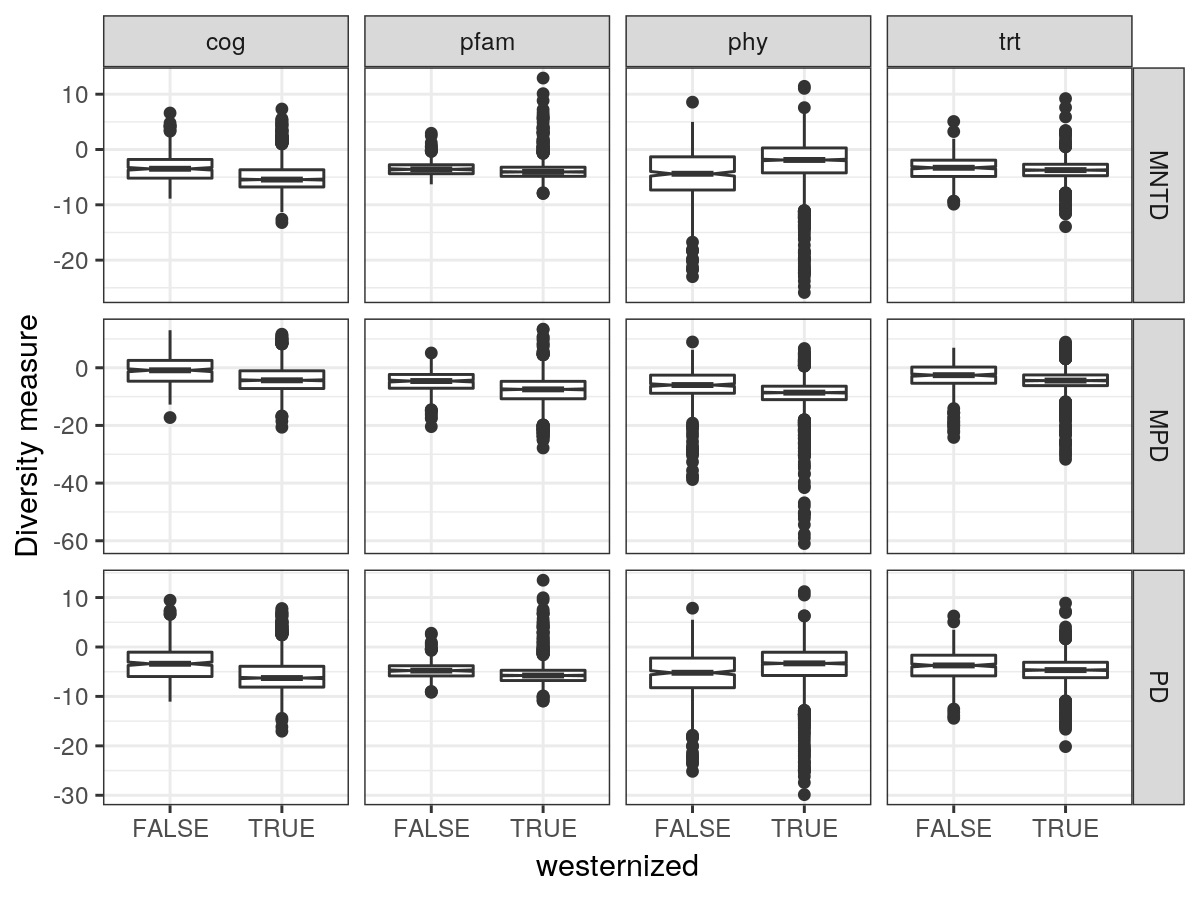

In [114]:
# plotting
p = alpha_res_f %>%
    filter.(!grepl('cat$', tree)) %>%
    ggplot(aes(westernized, diversity_value)) +
    geom_boxplot(notch=TRUE) +
    labs(y='Diversity measure') +
    facet_grid(diversity_measure ~ tree, scales='free_y') +
    theme_bw()
p.dims(6,4.5)
p

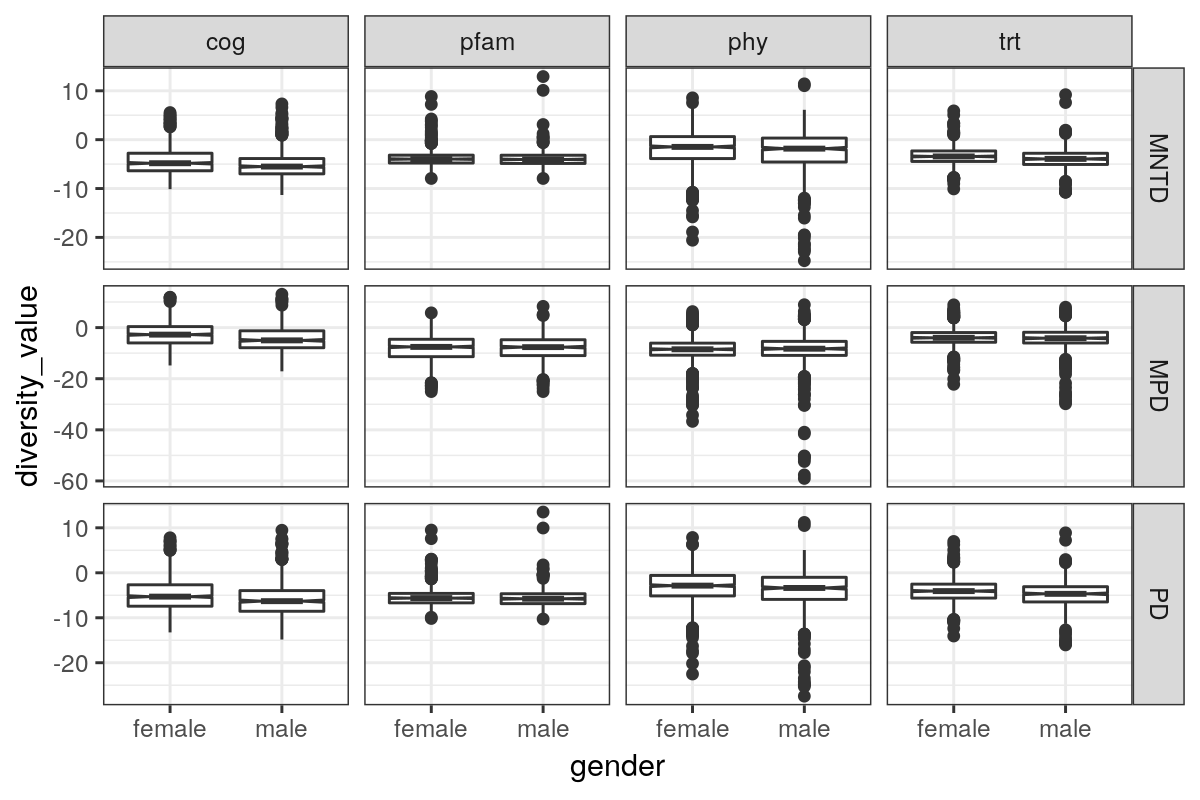

In [115]:
# plotting
p = alpha_res_f %>%
    filter.(!grepl('cat$', tree)) %>%
    filter.(!is.na(gender)) %>%
    ggplot(aes(gender, diversity_value)) +
    geom_boxplot(notch=TRUE) +
    facet_grid(diversity_measure ~ tree, scales='free_y') +
    theme_bw()
p.dims(6,4)
p

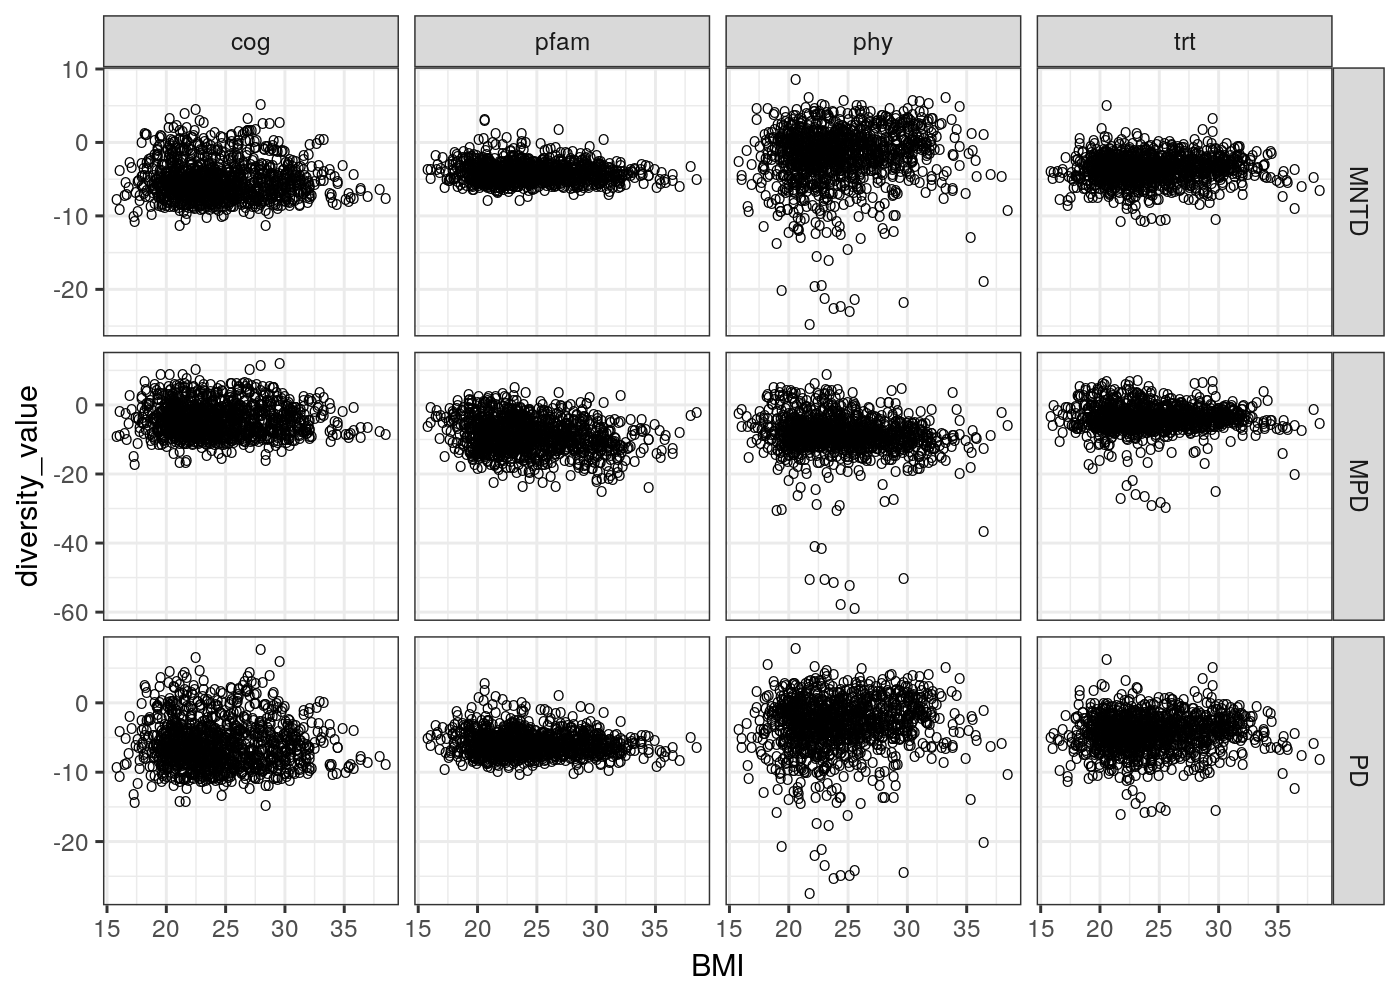

In [116]:
# plotting
p = alpha_res_f %>%
    filter.(!grepl('cat$', tree)) %>%
    filter.(!is.na(BMI),
            BMI < 40) %>%
    ggplot(aes(BMI, diversity_value)) +
    geom_point(shape='O') +
    facet_grid(diversity_measure ~ tree, scales='free_y') +
    theme_bw()
p.dims(7,5)
p

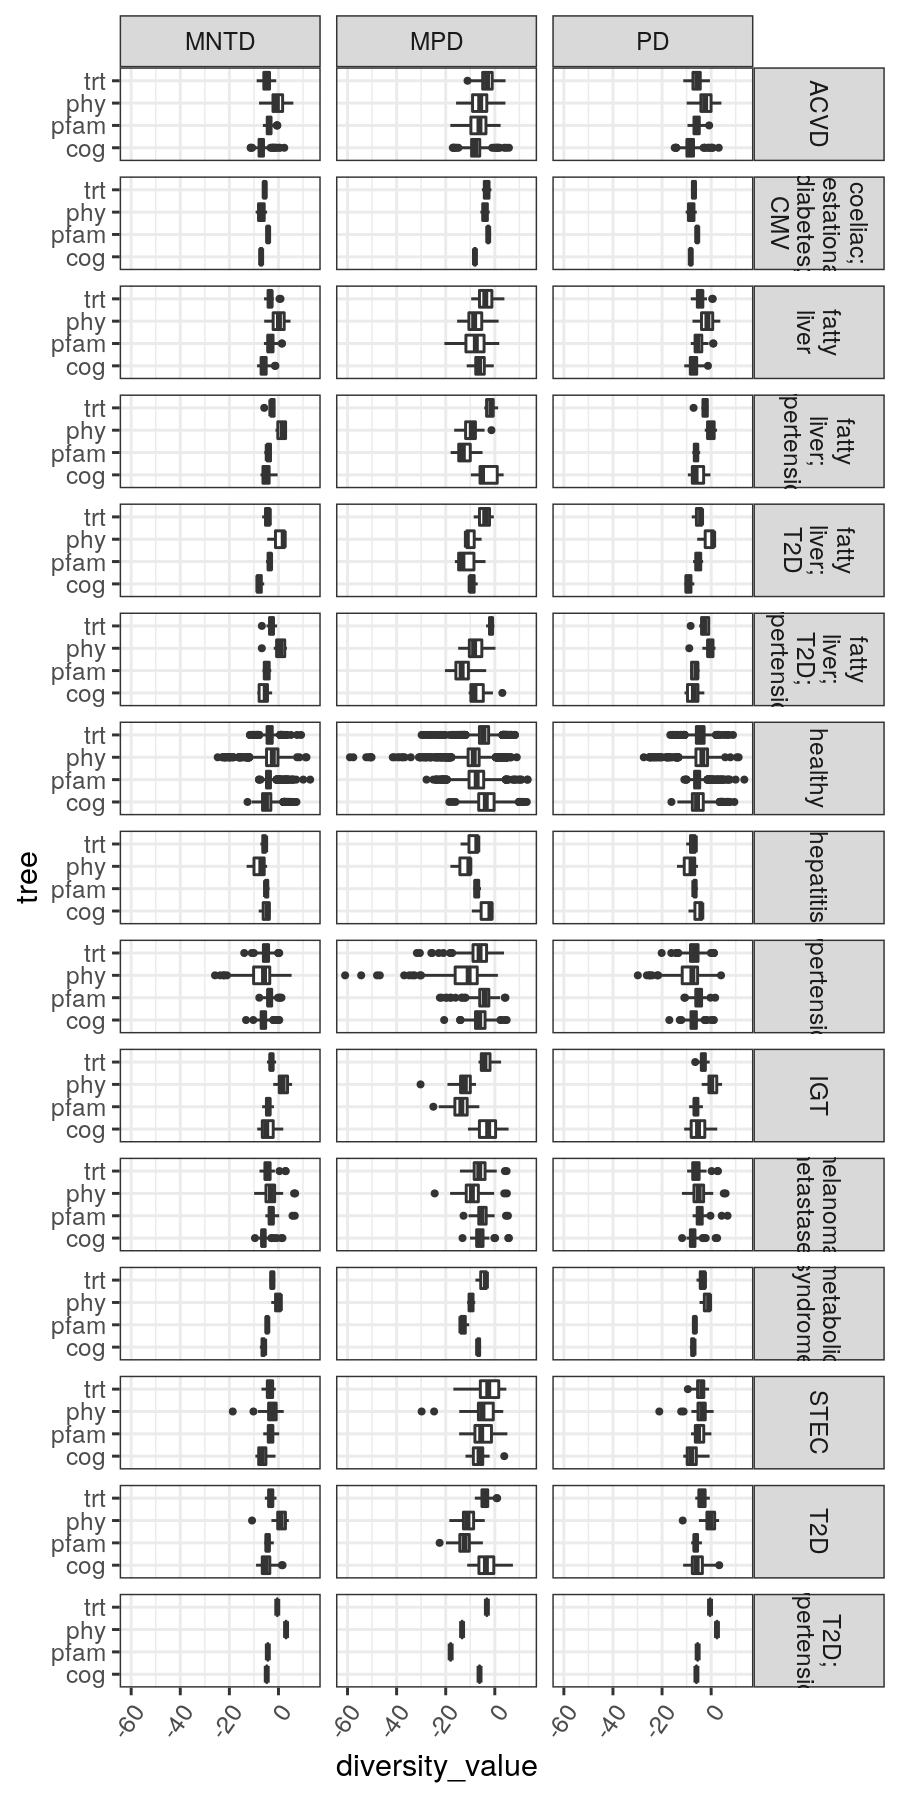

In [117]:
# plotting
p = alpha_res_f %>%
    filter.(!grepl('cat$', tree)) %>%
    filter.(!is.na(disease)) %>%
    mutate.(disease = gsub(';', '; ', disease),
            disease = gsub('_', ' ', disease),
            disease = stringr::str_wrap(disease, 0)) %>%
    ggplot(aes(tree, diversity_value)) +
    geom_boxplot(outlier.size = 0.7) +
    facet_grid(disease ~ diversity_measure, scales='free_y') +
    theme_bw() +
    theme(
        axis.text.x = element_text(angle=55, hjust=1)
    ) +
    coord_flip()
p.dims(4.5,9)
p

## LMER

In [120]:
library(lme4)
library(lmerTest)

### Westernized

In [32]:
LMER = function(df){
    res = lmer(diversity_value ~ westernized + (1 | dataset_name), data=df) 
    res = anova(res, type='II')
    res$coef = rownames(res)
    res$tree = df$tree[1]
    res$diversity_measure = df$diversity_measure[1]
    res$n = nrow(df)
    return(res)
}

In [33]:
lmer_res_m1 = alpha_res_f %>%
    filter.(!is.na(westernized)) %>%
    mutate.(age = log2(age),
            BMI = car::bcPower(BMI, -1)) %>%
    group_split.(tree, diversity_measure) %>%
    lapply(LMER) %>%
    do.call(rbind, .)
lmer_res_m1

Registered S3 methods overwritten by 'car':
  method                          from
  influence.merMod                lme4
  cooks.distance.influence.merMod lme4
  dfbeta.influence.merMod         lme4
  dfbetas.influence.merMod        lme4



,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F),coef,tree,diversity_measure,n
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>
westernized,16.89320,16.89320,1,769.3153,2.7933225,0.09506447,westernized,phy,PD,3348
westernized1,1.56597,1.56597,1,339.4363,0.5294018,0.46736003,westernized,trt,PD,3348
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
westernized16,99.210667697,99.210667697,1,1274.1867,6.1170538872,0.0135180,westernized,pfam,MPD,3348
westernized17,0.001581391,0.001581391,1,275.3687,0.0002057766,0.9885652,westernized,pfamcat,MPD,3348


### Westernized + age + gender

In [34]:
LMER = function(df){
    res = lmer(diversity_value ~ westernized + age + gender + (1 | dataset_name), data=df) 
    res = anova(res, type='II')
    res$coef = rownames(res)
    res$tree = df$tree[1]
    res$diversity_measure = df$diversity_measure[1]
    res$n = nrow(df)
    return(res)
}

In [35]:
lmer_res_m2 = alpha_res_f %>%
    filter.(!is.na(westernized),
            !is.na(age),
            !is.na(gender)) %>%
    mutate.(age = log2(age),
            BMI = car::bcPower(BMI, -1)) %>%
    group_split.(tree, diversity_measure) %>%
    lapply(LMER) %>%
    do.call(rbind, .)
lmer_res_m2

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F),coef,tree,diversity_measure,n
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>
westernized,5.77620,5.77620,1,77.41527,1.100019,2.975252e-01,westernized,phy,PD,1843
age,93.24943,93.24943,1,1803.46813,17.758419,2.631994e-05,age,phy,PD,1843
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
age17,31.83726,31.83726,1,1645.481,4.693339,0.030422911,age,pfamcat,MPD,1843
gender17,63.77843,63.77843,1,1837.966,9.401994,0.002199073,gender,pfamcat,MPD,1843


### Westernized + age + gender + BMI

In [57]:
LMER = function(df){
    res = lmer(diversity_value ~ westernized + age + gender + BMI + (1 | dataset_name), data=df) 
    res = anova(res, type='II')
    res$coef = rownames(res)
    res$tree = df$tree[1]
    res$diversity_measure = df$diversity_measure[1]
    res$n = nrow(df)
    return(res)
}

In [58]:
lmer_res_m3 = alpha_res_f %>%
    filter.(!is.na(westernized),
            !is.na(age),
            !is.na(gender),
            !is.na(BMI)) %>%
    mutate.(age = log2(age),
            BMI = car::bcPower(BMI, -1)) %>%
    group_split.(tree, diversity_measure) %>%
    lapply(LMER) %>%
    do.call(rbind, .)
lmer_res_m3

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F),coef,tree,diversity_measure,n
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>
westernized,1.24156,1.24156,1,99.68157,0.21510,0.6438103132,westernized,phy,PD,935
age,69.77665,69.77665,1,929.12056,12.08879,0.0005307601,age,phy,PD,935
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
gender17,39.23269,39.23269,1,927.2948,4.890553,0.027247282,gender,pfamcat,MPD,935
BMI17,81.60440,81.60440,1,928.0963,10.172401,0.001473379,BMI,pfamcat,MPD,935


### Westernized + age + gender + disease status

In [76]:
LMER = function(df){
    res = lmer(diversity_value ~ westernized + age + gender + disease_status + (1 | dataset_name), data=df) 
    res = anova(res, type='II')
    res$coef = rownames(res)
    res$tree = df$tree[1]
    res$diversity_measure = df$diversity_measure[1]
    res$n = nrow(df)
    return(res)
}

In [77]:
lmer_res_m4 = alpha_res_f %>%
    mutate.(disease_status = ifelse(disease != 'healthy', 'diseased', disease)) %>%
    filter.(!is.na(westernized),
            !is.na(age),
            !is.na(gender),
            !is.na(disease_status)) %>%
    mutate.(age = log2(age)) %>%
    group_split.(tree, diversity_measure) %>%
    lapply(LMER) %>%
    do.call(rbind, .)
lmer_res_m4

,Sum Sq,Mean Sq,NumDF,DenDF,F value,Pr(>F),coef,tree,diversity_measure,n
,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>
westernized,2.740684,2.740684,1,92.20067,0.4893037,4.859991e-01,westernized,phy,PD,1413
age,94.533278,94.533278,1,1382.07314,16.8773510,4.221582e-05,age,phy,PD,1413
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
gender17,59.76055,59.76055,1,1407.9245,8.289162,0.004048523,gender,pfamcat,MPD,1413
disease_status17,11.15876,11.15876,1,844.9265,1.547790,0.213806942,disease_status,pfamcat,MPD,1413


### Merging: models 1-2-3

In [61]:
lmer_res = list(
    m1 = lmer_res_m1,
    m2 = lmer_res_m2,
    m3 = lmer_res_m3) %>%
    rbindlist(use.names=TRUE, idcol='lmer_model') %>%
    rename.('P' = `Pr(>F)`,
            'F' = `F value`,
            'Method' = tree)
lmer_res    

lmer_model,Sum Sq,Mean Sq,NumDF,DenDF,F,P,coef,Method,diversity_measure,n
<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>
m1,16.89320,16.89320,1,769.3153,2.7933225,0.09506447,westernized,phy,PD,3348
m1,1.56597,1.56597,1,339.4363,0.5294018,0.46736003,westernized,trt,PD,3348
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
m3,39.23269,39.23269,1,927.2948,4.890553,0.027247282,gender,pfamcat,MPD,935
m3,81.60440,81.60440,1,928.0963,10.172401,0.001473379,BMI,pfamcat,MPD,935


Warning message:
“Removed 5 rows containing missing values (geom_bar).”
Warning message:
“Removed 5 rows containing missing values (geom_text).”


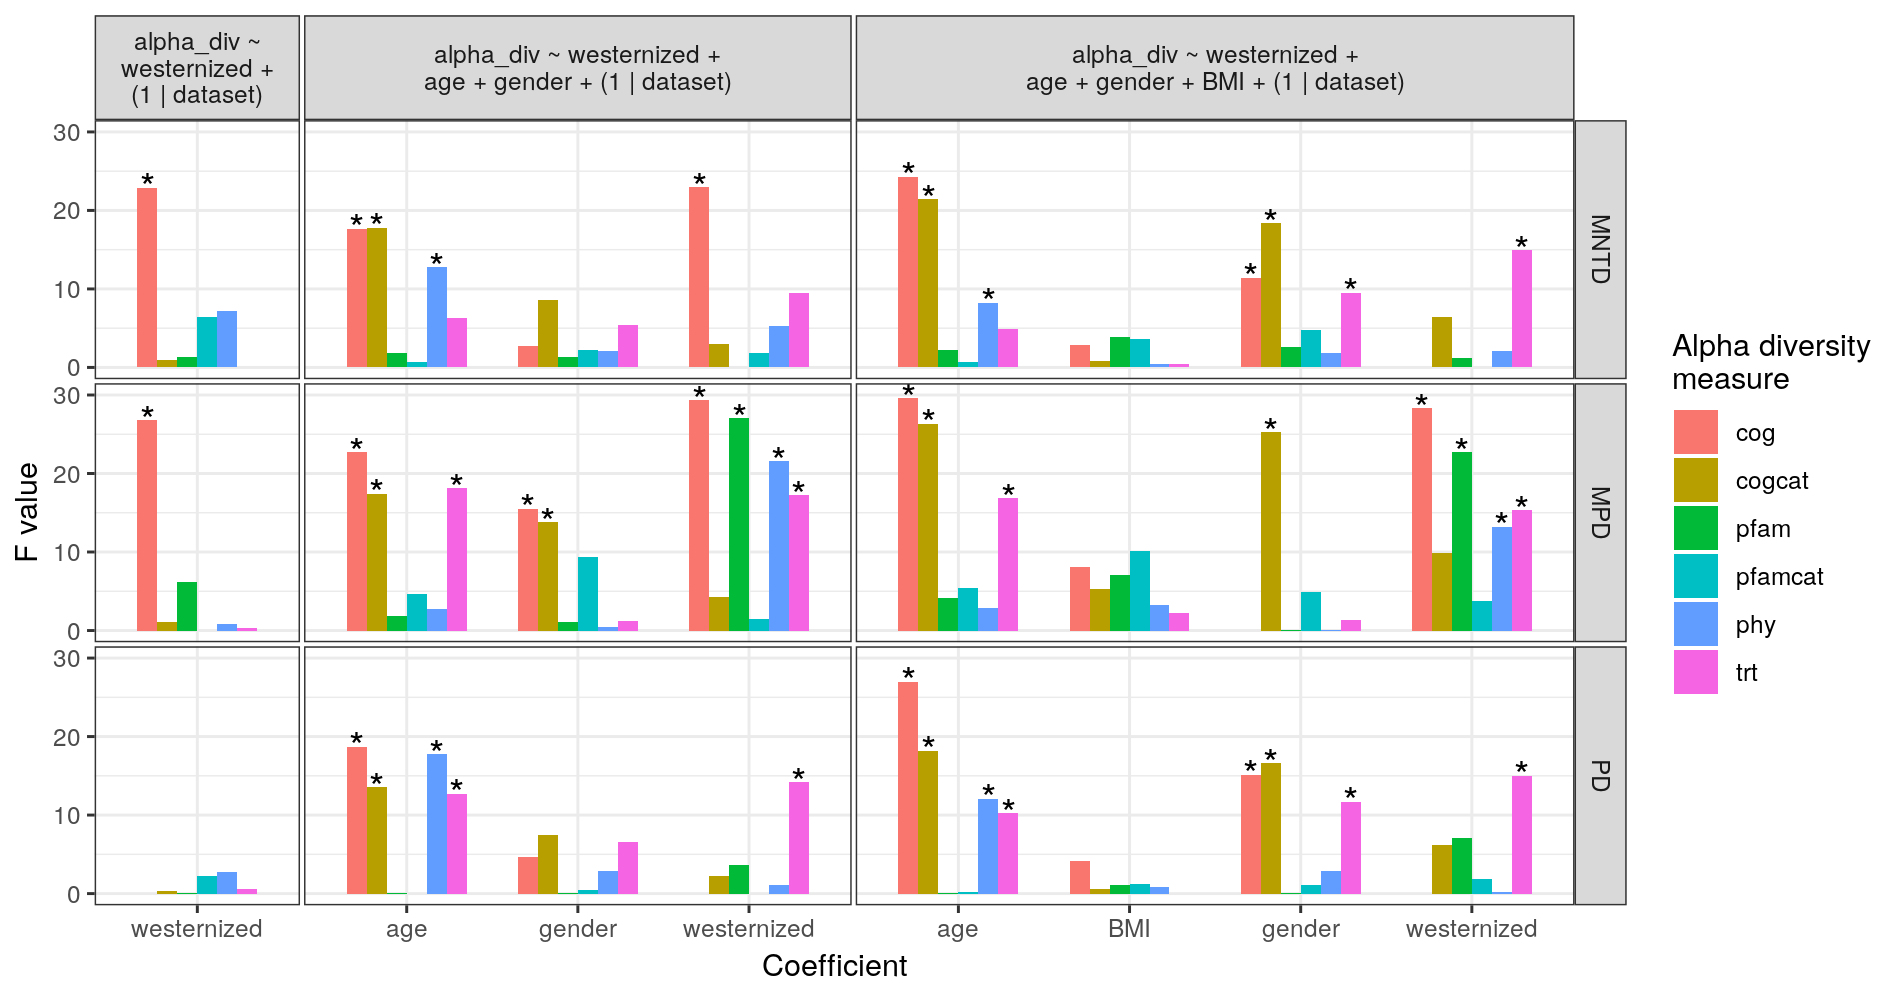

In [62]:
p = lmer_res %>%
    mutate.(q_val = p.adjust(as.Num(P), method='BH'),
            .by=c(lmer_model, coef)) %>%
    mutate.(sig = ifelse(q_val < 0.01, '*', '')) %>%
    mutate.(lmer_model = case.(lmer_model == 'm1',
                               'alpha_div ~\nwesternized +\n(1 | dataset)',
                               lmer_model == 'm2',
                               'alpha_div ~ westernized +\nage + gender + (1 | dataset)',
                               lmer_model == 'm3',
                               'alpha_div ~ westernized +\nage + gender + BMI + (1 | dataset)')) %>%
    ggplot(aes(coef, F, fill=Method)) +
    geom_bar(stat='identity', position='dodge', width=0.7) +
    geom_text(aes(label=sig), size=5,
                  position=position_dodge(width=0.7)) +
    scale_fill_discrete('Alpha diversity\nmeasure') +
    scale_y_continuous(limits=c(0,30)) +
    labs(x='Coefficient', y='F value') +
    facet_grid(diversity_measure ~ lmer_model, scales='free_x', space='free_x') +
    theme_bw() +
    theme(
        panel.spacing = unit(0.1, "lines")
    )

p.dims(9.5,5)
plot(p)

Warning message:
“Removed 2 rows containing missing values (geom_bar).”
Warning message:
“Removed 2 rows containing missing values (geom_text).”


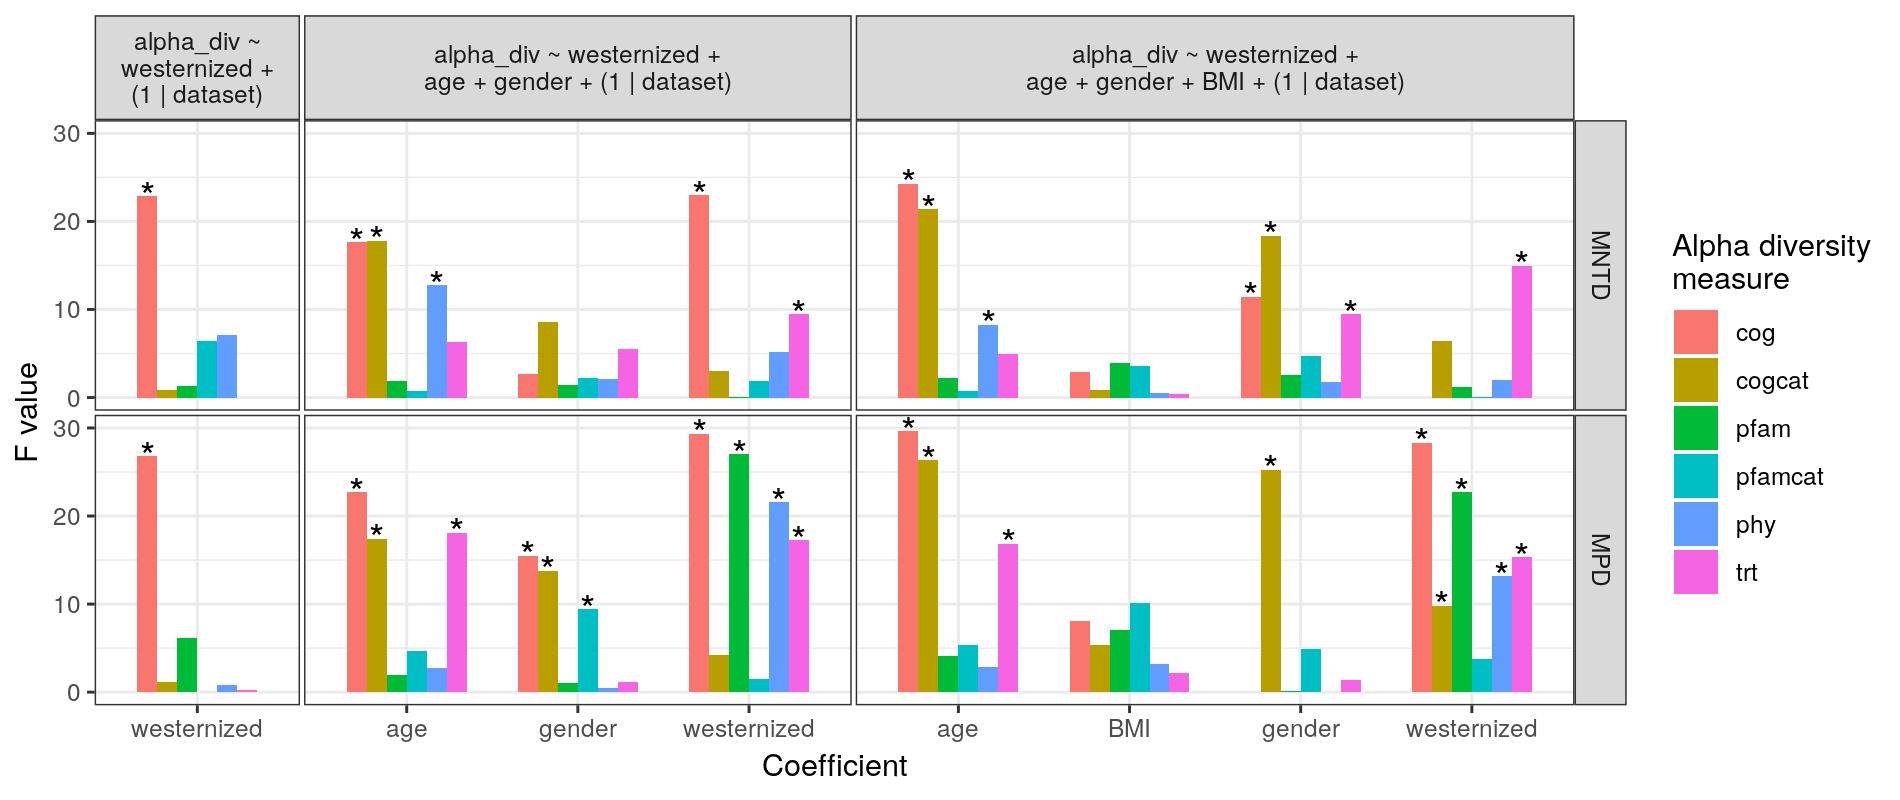

In [63]:
p = lmer_res %>%
    filter.(diversity_measure != 'PD') %>%
    mutate.(q_val = p.adjust(as.Num(P), method='BH'),
            .by=c(lmer_model, coef)) %>%
    mutate.(sig = ifelse(q_val < 0.01, '*', '')) %>%
    mutate.(lmer_model = case.(lmer_model == 'm1',
                               'alpha_div ~\nwesternized +\n(1 | dataset)',
                               lmer_model == 'm2',
                               'alpha_div ~ westernized +\nage + gender + (1 | dataset)',
                               lmer_model == 'm3',
                               'alpha_div ~ westernized +\nage + gender + BMI + (1 | dataset)')) %>%
    ggplot(aes(coef, F, fill=Method)) +
    geom_bar(stat='identity', position='dodge', width=0.7) +
    geom_text(aes(label=sig), size=5,
                  position=position_dodge(width=0.7)) +
    scale_fill_discrete('Alpha diversity\nmeasure') +
    scale_y_continuous(limits=c(0,30)) +
    labs(x='Coefficient', y='F value') +
    facet_grid(diversity_measure ~ lmer_model, scales='free_x', space='free_x') +
    theme_bw() +
    theme(
        panel.spacing = unit(0.1, "lines")
    )

p.dims(9.5,4)
plot(p)

Warning message:
“Removed 2 rows containing missing values (geom_bar).”
Warning message:
“Removed 2 rows containing missing values (geom_text).”


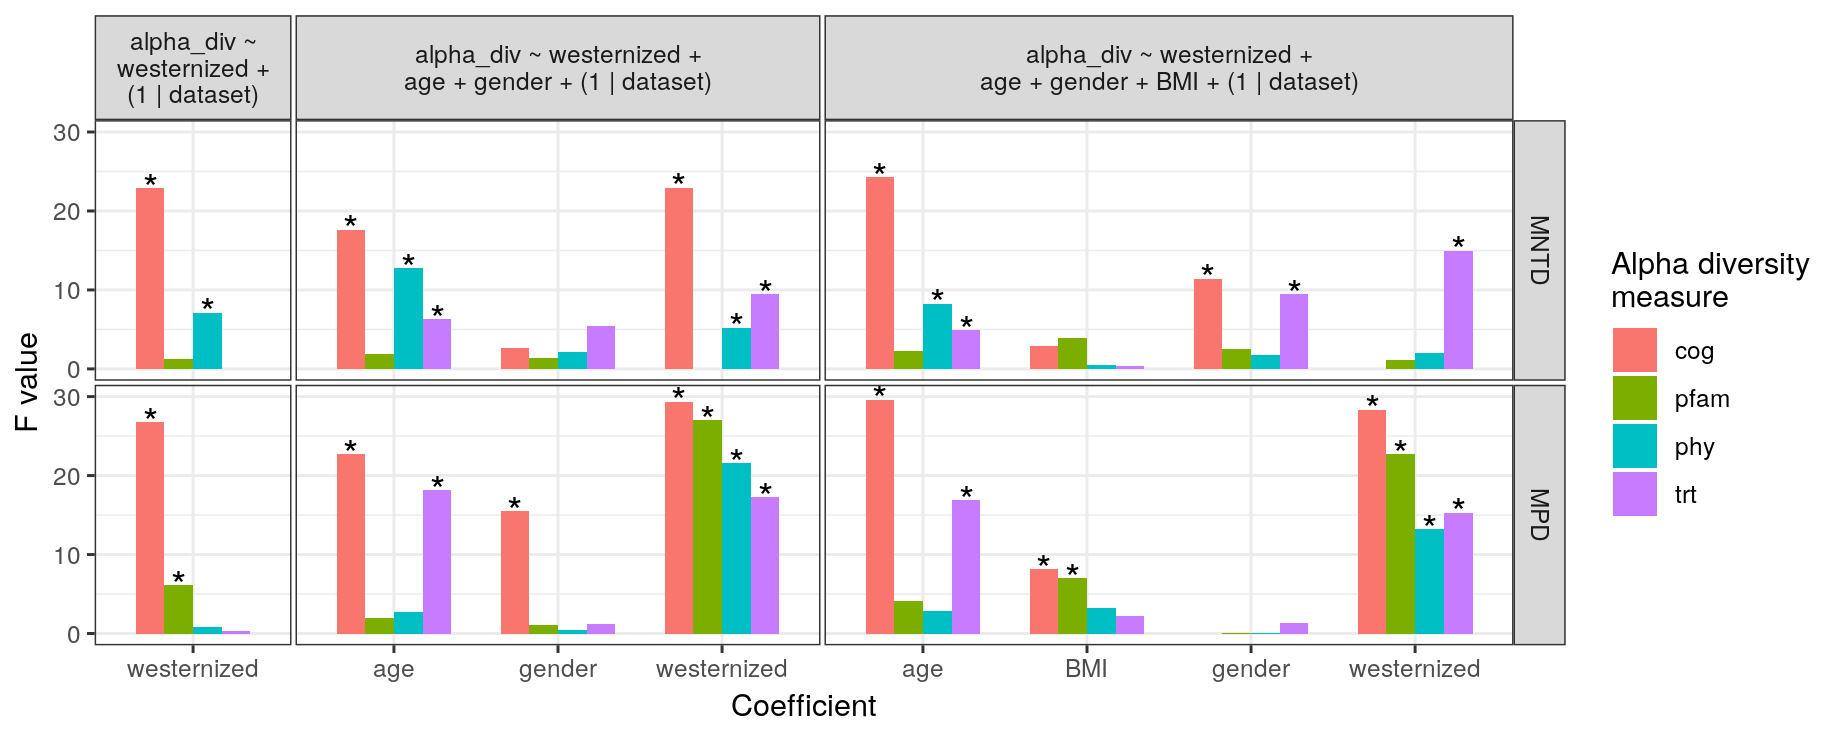

In [64]:
p = lmer_res %>%
    filter.(!grepl('cat$', Method)) %>%
    filter.(diversity_measure != 'PD') %>%
    mutate.(q_val = p.adjust(as.Num(P), method='BH'),
            .by=c(lmer_model, coef)) %>%
    mutate.(sig = ifelse(q_val < 0.05, '*', '')) %>%
    mutate.(lmer_model = case.(lmer_model == 'm1',
                               'alpha_div ~\nwesternized +\n(1 | dataset)',
                               lmer_model == 'm2',
                               'alpha_div ~ westernized +\nage + gender + (1 | dataset)',
                               lmer_model == 'm3',
                               'alpha_div ~ westernized +\nage + gender + BMI + (1 | dataset)')) %>%
    ggplot(aes(coef, F, fill=Method)) +
    geom_bar(stat='identity', position='dodge', width=0.7) +
    geom_text(aes(label=sig), size=5,
                  position=position_dodge(width=0.7)) +
    scale_fill_discrete('Alpha diversity\nmeasure') +
    scale_y_continuous(limits=c(0,30)) +
    labs(x='Coefficient', y='F value') +
    facet_grid(diversity_measure ~ lmer_model, scales='free_x', space='free_x') +
    theme_bw() +
    theme(
        panel.spacing = unit(0.1, "lines")
    )

p.dims(9.2,3.7)
plot(p)

### Merging: modesl 1-2-4

In [78]:
lmer_res = list(
    m1 = lmer_res_m1,
    m2 = lmer_res_m2,
    m4 = lmer_res_m4) %>%
    rbindlist(use.names=TRUE, idcol='lmer_model') %>%
    rename.('P' = `Pr(>F)`,
            'F' = `F value`,
            'Method' = tree)
lmer_res    

lmer_model,Sum Sq,Mean Sq,NumDF,DenDF,F,P,coef,Method,diversity_measure,n
<chr>,<dbl>,<dbl>,<int>,<dbl>,<dbl>,<dbl>,<chr>,<chr>,<chr>,<int>
m1,16.89320,16.89320,1,769.3153,2.7933225,0.09506447,westernized,phy,PD,3348
m1,1.56597,1.56597,1,339.4363,0.5294018,0.46736003,westernized,trt,PD,3348
⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮,⋮
m4,59.76055,59.76055,1,1407.9245,8.289162,0.004048523,gender,pfamcat,MPD,1413
m4,11.15876,11.15876,1,844.9265,1.547790,0.213806942,disease_status,pfamcat,MPD,1413


Warning message:
“Removed 2 rows containing missing values (geom_bar).”
Warning message:
“Removed 2 rows containing missing values (geom_text).”


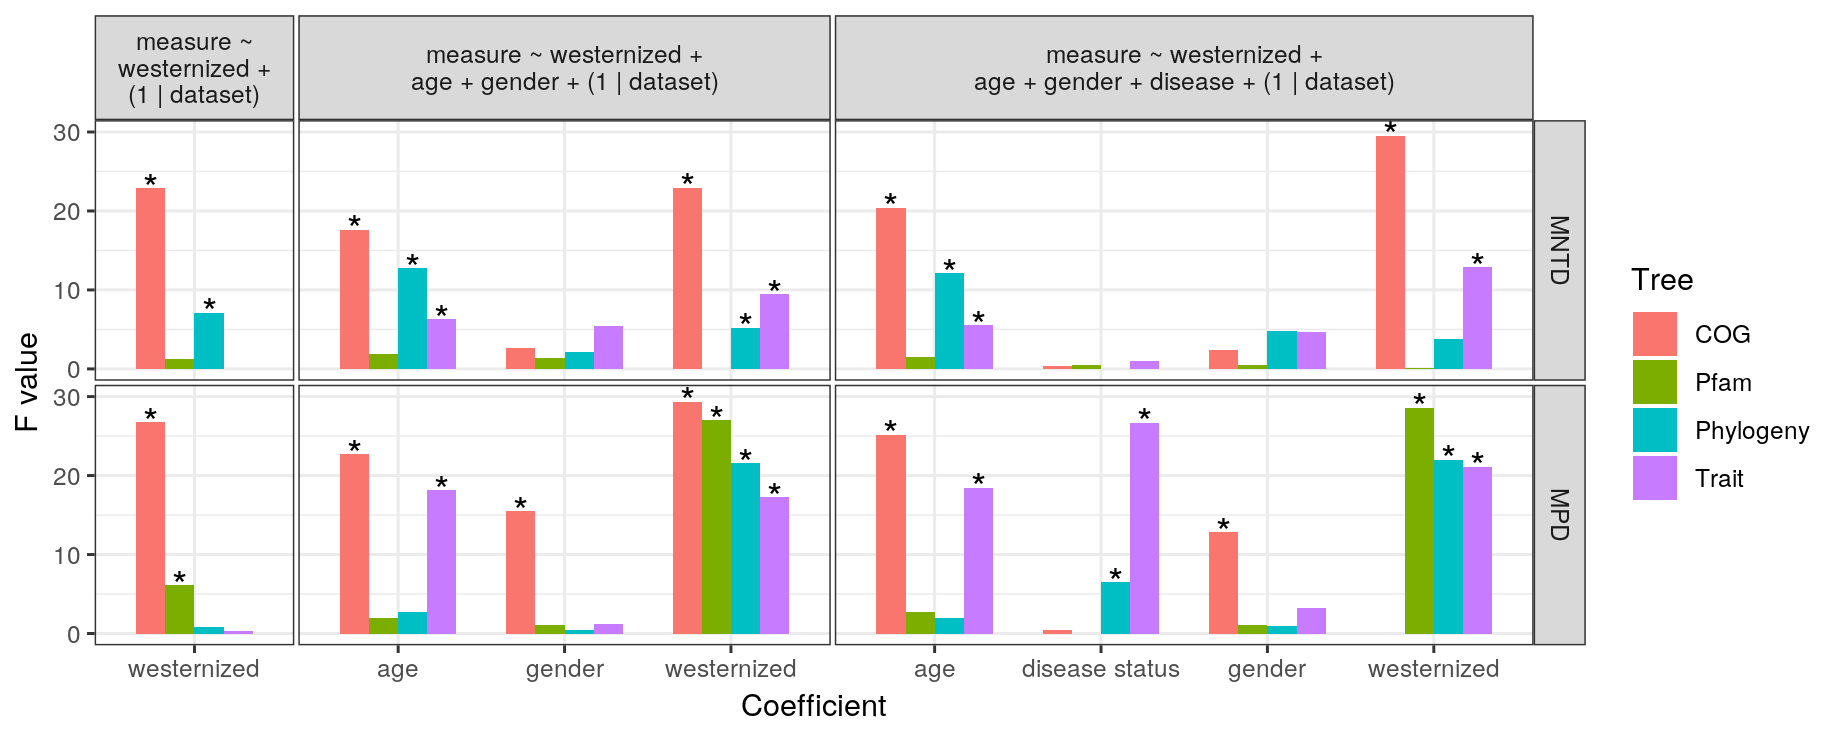

In [133]:
p = lmer_res %>%
    filter.(!grepl('cat$', Method)) %>%
    filter.(diversity_measure != 'PD') %>%
    mutate.(q_val = p.adjust(as.Num(P), method='BH'),
            .by=c(lmer_model, coef)) %>%
    mutate.(sig = ifelse(q_val < 0.05, '*', '')) %>%
    mutate.(coef = gsub('_', ' ', coef)) %>%
    mutate.(Method = case.(Method == 'cog', 'COG',
                           Method == 'pfam', 'Pfam',
                           Method == 'phy', 'Phylogeny',
                           Method == 'trt', 'Trait')) %>%
    mutate.(lmer_model = case.(lmer_model == 'm1',
                               'measure ~\nwesternized +\n(1 | dataset)',
                               lmer_model == 'm2',
                               'measure ~ westernized +\nage + gender + (1 | dataset)',
                               lmer_model == 'm4',
                               'measure ~ westernized +\nage + gender + disease + (1 | dataset)')) %>%
    ggplot(aes(coef, F, fill=Method)) +
    geom_bar(stat='identity', position='dodge', width=0.7) +
    geom_text(aes(label=sig), size=5,
                  position=position_dodge(width=0.7)) +
    scale_fill_discrete('Tree') +
    scale_y_continuous(limits=c(0,30)) +
    labs(x='Coefficient', y='F value') +
    facet_grid(diversity_measure ~ lmer_model, scales='free_x', space='free_x') +
    theme_bw() +
    theme(
        panel.spacing = unit(0.1, "lines")
    )

p.dims(9.2,3.7)
plot(p)

# sessionInfo

In [232]:
sessionInfo()

R version 4.0.3 (2020-10-10)
Platform: x86_64-conda-linux-gnu (64-bit)
Running under: Ubuntu 18.04.5 LTS

Matrix products: default
BLAS/LAPACK: /ebio/abt3_projects/Georg_animal_feces/envs/function/lib/libopenblasp-r0.3.10.so

locale:
 [1] LC_CTYPE=en_US.UTF-8       LC_NUMERIC=C              
 [3] LC_TIME=en_US.UTF-8        LC_COLLATE=en_US.UTF-8    
 [5] LC_MONETARY=en_US.UTF-8    LC_MESSAGES=en_US.UTF-8   
 [7] LC_PAPER=en_US.UTF-8       LC_NAME=C                 
 [9] LC_ADDRESS=C               LC_TELEPHONE=C            
[11] LC_MEASUREMENT=en_US.UTF-8 LC_IDENTIFICATION=C       

attached base packages:
[1] stats     graphics  grDevices utils     datasets  methods   base     

other attached packages:
 [1] lmerTest_3.1-3     lme4_1.1-26        Matrix_1.2-18      clustermq_0.8.95.1
 [5] LeyLabRMisc_0.1.6  PhyloMeasures_2.1  ape_5.4-1          tidytable_0.5.6   
 [9] data.table_1.13.2  ggplot2_3.3.2      tidyr_1.1.2        dplyr_1.0.2       

loaded via a namespace (and not attached):
